In [ ]:
## Kaggle competition : Titanic

import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
print(train_data.head())
print(test_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [24]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [26]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [28]:
# here we can see that the age column has a lot of missing values but we now too that it's an important feature in predicting survival so we will try to fill the missing values with the median of the age column
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
# we see that the cabin feature has a lot of missing values more than the half for the training data are missing and more than 70% for the test data so we will drop this feature from our dataset
train_data.drop(columns=['Cabin'], inplace=True)
test_data.drop(columns=['Cabin'], inplace=True)

/tmp/ipykernel_227265/4093788829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
/tmp/ipykernel_227265/4093788829.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [29]:
print(f'train data: {train_data.describe()}')
print(f'test data: {test_data.describe()}')
print(f'train data values: {train_data.head()}')
print(f'test data values: {test_data.head()}')
test_data.info()
train_data.info()


train data:        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
test data:        PassengerId      Pclass         Age       SibSp    

In [30]:
# we can see that the datas are normalized and there are no missing values anymore so we can start building our model
# first let's encode the categorical features

train_data = pd.get_dummies(train_data, columns=['Sex', 'Embarked'], drop_first=True)
test_data = pd.get_dummies(test_data, columns=['Sex', 'Embarked'], drop_first=True)

# let's encode the others string features and create new features from the existing ones
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1

train_data['pronounce'] = train_data['Name'].apply(lambda x: 1 if 'Mr.' in x else (2 if 'Mrs.' in x else (3 if 'Miss.' in x else 4)))
test_data['pronounce'] = test_data['Name'].apply(lambda x: 1 if 'Mr.' in x else (2 if 'Mrs.' in x else (3 if 'Miss.' in x else 4)))


print(train_data.head())
print(test_data.head())





   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Sex_male  Embarked_Q  Embarked_S  FamilySize  \
0         A/5 21171   7.2500      True       False        True           2   
1          PC 17599  71.2833     False       False       False           2   
2  STON/O2. 3101282   7.9250     False       False        True           1   
3            1

In [31]:
# let's delete the name and ticket features since they are not useful for our model
train_data.drop(columns=['Name', 'Ticket'], inplace=True)
test_data.drop(columns=['Name', 'Ticket'], inplace=True)

print(train_data.head())
print(test_data.head())

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  \
0            1         0       3  22.0      1      0   7.2500      True   
1            2         1       1  38.0      1      0  71.2833     False   
2            3         1       3  26.0      0      0   7.9250     False   
3            4         1       1  35.0      1      0  53.1000     False   
4            5         0       3  35.0      0      0   8.0500      True   

   Embarked_Q  Embarked_S  FamilySize  pronounce  
0       False        True           2          1  
1       False       False           2          2  
2       False        True           1          3  
3       False        True           2          2  
4       False        True           1          1  
   PassengerId  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0          892       3  34.5      0      0   7.8292      True        True   
1          893       3  47.0      1      0   7.0000     False       False   
2          8

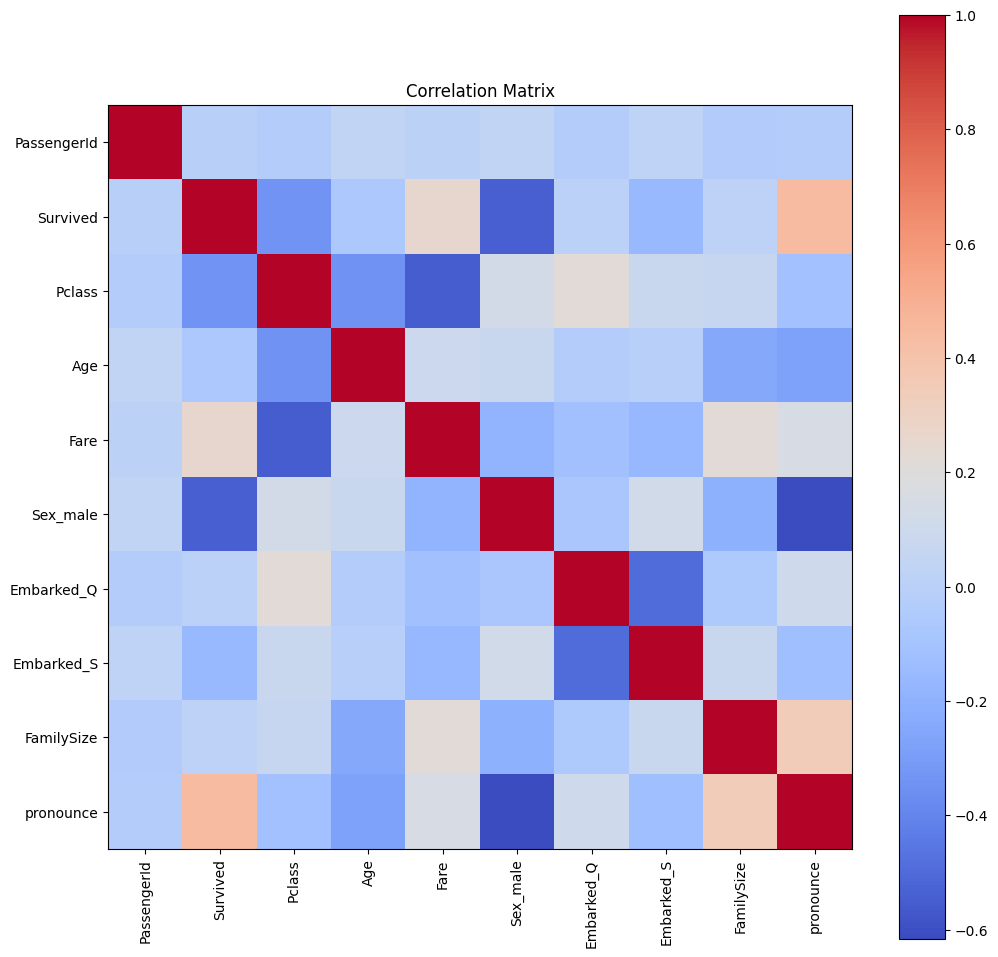

             PassengerId  Survived    Pclass       Age      Fare  Sex_male  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212  0.012658  0.042939   
Survived       -0.005007  1.000000 -0.338481 -0.064910  0.257307 -0.543351   
Pclass         -0.035144 -0.338481  1.000000 -0.339898 -0.549500  0.131900   
Age             0.034212 -0.064910 -0.339898  1.000000  0.096688  0.081163   
Fare            0.012658  0.257307 -0.549500  0.096688  1.000000 -0.182333   
Sex_male        0.042939 -0.543351  0.131900  0.081163 -0.182333  1.000000   
Embarked_Q     -0.033606  0.003650  0.221009 -0.031415 -0.117216 -0.074115   
Embarked_S      0.022148 -0.155660  0.081720 -0.014665 -0.166603  0.125722   
FamilySize     -0.040143  0.016639  0.065997 -0.245619  0.217138 -0.200988   
pronounce      -0.035254  0.438282 -0.105601 -0.280914  0.148783 -0.616374   

             Embarked_Q  Embarked_S  FamilySize  pronounce  
PassengerId   -0.033606    0.022148   -0.040143  -0.035254  
Survived       0.00

In [32]:
# here we will try to display the correlation matrix of the features to see if there are any features that are highly correlated with the target variable (Survived) and also to see if there are any features that are highly correlated with each other which can cause multicollinearity issues in our model

# let's drop the unusefull features
train_data.drop(columns=['SibSp', 'Parch'], inplace=True)
test_data.drop(columns=['SibSp', 'Parch'], inplace=True)


train_corr_matrix = train_data.corr()
plt.figure(figsize=(12, 12))
plt.imshow(train_corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(train_corr_matrix)), train_corr_matrix.columns, rotation=90)
plt.yticks(range(len(train_corr_matrix)), train_corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

print(train_corr_matrix)


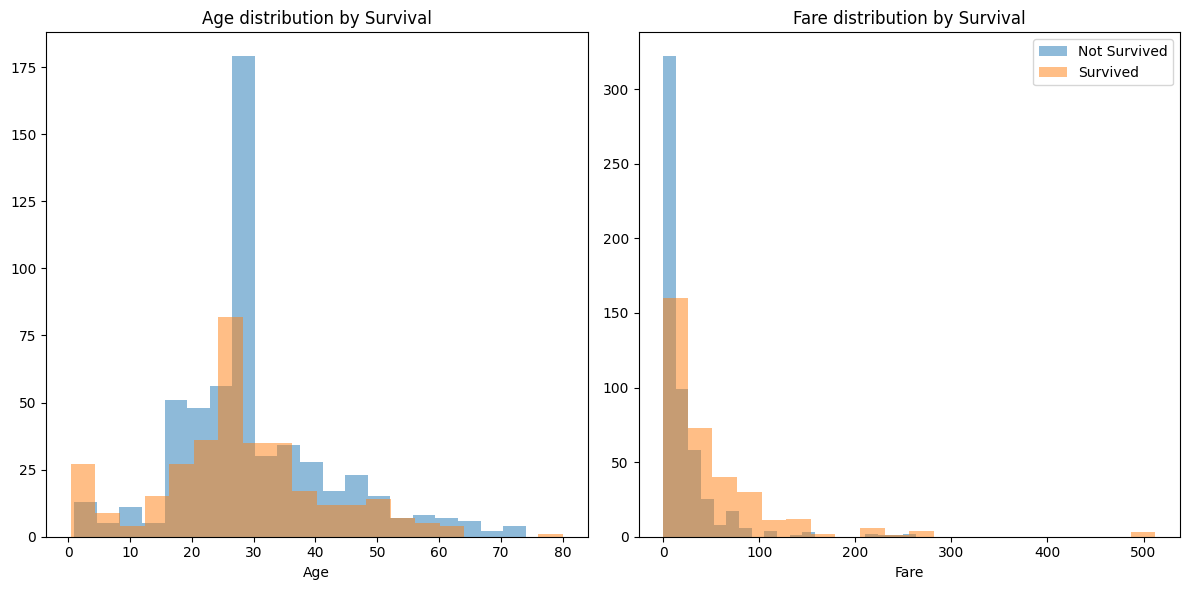

In [33]:
# regardons un peu la repartition des données pour les features les plus corrélées avec la variable cible (Survived) pour voir si il y a des outliers ou des valeurs aberrantes qui peuvent influencer notre modèle

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(train_data[train_data['Survived'] == 0]['Age'], bins=20, alpha=0.5, label='Not Survived')
plt.hist(train_data[train_data['Survived'] == 1]['Age'], bins=20, alpha=0.5, label='Survived')
plt.title('Age distribution by Survival')
plt.xlabel('Age')   

plt.subplot(1, 2, 2)
plt.hist(train_data[train_data['Survived'] == 0]['Fare'], bins=20, alpha=0.5, label='Not Survived')
plt.hist(train_data[train_data['Survived'] == 1]['Fare'], bins=20, alpha=0.5, label='Survived')
plt.title('Fare distribution by Survival')
plt.xlabel('Fare')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:

# we can see that the fare is missing one value let's fill it with the median of the fare column
train_data['Fare'].fillna(train_data['Fare'].median(), inplace=True)
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)

# we have seen too that there's possibly some outliers in the fare column so we will try to use the log transformation to reduce the effect of the outliers and make the distribution more normal
train_data['Fare'] = np.log1p(train_data['Fare'])
test_data['Fare'] = np.log1p(test_data['Fare'])

print(train_data.describe())
print(test_data.describe())


       PassengerId    Survived      Pclass         Age        Fare  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    2.962246   
std     257.353842    0.486592    0.836071   13.019697    0.969048   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    2.187218   
50%     446.000000    0.000000    3.000000   28.000000    2.737881   
75%     668.500000    1.000000    3.000000   35.000000    3.465736   
max     891.000000    1.000000    3.000000   80.000000    6.240917   

       FamilySize   pronounce  
count  891.000000  891.000000  
mean     1.904602    1.774411  
std      1.613459    1.017629  
min      1.000000    1.000000  
25%      1.000000    1.000000  
50%      1.000000    1.000000  
75%      2.000000    3.000000  
max     11.000000    4.000000  
       PassengerId      Pclass         Age        Fare  FamilySize   pronounce
co

/tmp/ipykernel_227265/4264337906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Fare'].fillna(train_data['Fare'].median(), inplace=True)
/tmp/ipykernel_227265/4264337906.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [35]:
# now let's try to build our model and see how it performs on the test data
# we will try to use Logistic Regression and Random Forest Classifier and compare their performance using cross-validation and also using the test data to see which one performs better on unseen data
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Y = train_data["Survived"]
X = train_data.drop(columns=["Survived"])
model = LogisticRegression(max_iter=200)
model.fit(X, Y)
predictions = model.predict(test_data)
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission_logistic_regression.csv', index=False)
print("Logistic Regression submission was successfully saved!")

model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
model.fit(X, Y)
predictions = model.predict(test_data)
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission_random_forest.csv', index=False)
print("Random Forest submission was successfully saved!")

# let's compare the performance of the two models using cross-validation
logistic_cv_scores = cross_val_score(LogisticRegression(max_iter=200), X, Y, cv=5)
random_forest_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42), X, Y, cv=5)
print(f'Logistic Regression CV Scores: {logistic_cv_scores}')
print(f'Random Forest CV Scores: {random_forest_cv_scores}')


/home/bakemono/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression submission was successfully saved!
Random Forest submission was successfully saved!


/home/bakemono/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bakemono/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

Logistic Regression CV Scores: [0.81564246 0.80337079 0.78089888 0.81460674 0.80898876]
Random Forest CV Scores: [0.78212291 0.8258427  0.8258427  0.80337079 0.83146067]
